In [3]:
import sys
sys.executable

'/Users/fadhila/decisionnel-kpi-dashboard/.venv/bin/python'

# Ad-hoc Procurement Analysis (Kaggle)

Goal: provide business-ready insights on procurement performance using:
- financial KPIs (spend, savings)
- operational KPIs (lead time)
- quality & compliance signals
- data quality checks

In [4]:
import pandas as pd
import numpy as np

DATA_PATH = "../../data/processed/procurement_processed.parquet"
df = pd.read_parquet(DATA_PATH)

df.shape, df.columns

((777, 19),
 Index(['PO_ID', 'Supplier', 'Order_Date', 'Delivery_Date', 'Item_Category',
        'Order_Status', 'Quantity', 'Unit_Price', 'Negotiated_Price',
        'Defective_Units', 'Compliance', 'Lead_Time_Days', 'Total_Spend',
        'List_Spend', 'Savings', 'Savings_Rate', 'Defect_Rate', 'Is_Compliant',
        'Is_Delivered'],
       dtype='object'))

In [5]:
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Lead_Time_Days,Total_Spend,List_Spend,Savings,Savings_Rate,Defect_Rate,Is_Compliant,Is_Delivered
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,0.0,Yes,8.0,20944.56,23672.88,2728.32,0.115251,0.000000,True,False
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,10.0,56346.06,59333.88,2987.82,0.050356,0.155732,True,True
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,20.0,83956.60,86914.10,2957.50,0.034028,0.045055,True,True
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,19.0,128378.88,134198.40,5819.52,0.043365,0.083333,True,True
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,12.0,71425.40,75602.60,4177.20,0.055252,0.144915,False,True


## 1) Data quality

In [6]:
missing_by_col = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_by_col[missing_by_col > 0]

Lead_Time_Days    11.33
Delivery_Date     11.20
dtype: float64

In [7]:
rows_with_missing = (df.isna().any(axis=1).mean() * 100).round(2)
rows_with_missing

np.float64(11.33)

In [8]:
dup_po_id_rate = (df["PO_ID"].duplicated().mean() * 100).round(2)
dup_po_id_rate

np.float64(0.0)

### Interpretation

Missing values are mainly observed in `Delivery_Date` and therefore `Lead_Time_Days`.
This typically indicates **orders not yet delivered**.

For lead time KPIs, we compute and interpret results on **delivered orders only**.

## 2) Supplier deep-dive

In [9]:
delivered = df[df["Is_Delivered"] & df["Delivery_Date"].notna()].copy()
delivered.shape

(492, 19)

In [10]:
top_spend = (
    delivered.groupby("Supplier", as_index=False)["Total_Spend"]
    .sum()
    .sort_values("Total_Spend", ascending=False)
    .head(10)
)
top_spend

,Supplier,Total_Spend
3,Epsilon_Group,6334035.03
1,Beta_Supplies,6088787.63
4,Gamma_Co,5916036.75
2,Delta_Logistics,5723560.76
0,Alpha_Inc,4955432.51


In [11]:
top_savings = (
    delivered.groupby("Supplier", as_index=False)["Savings"]
    .sum()
    .sort_values("Savings", ascending=False)
    .head(10)
)
top_savings

,Supplier,Savings
1,Beta_Supplies,540992.22
3,Epsilon_Group,505960.88
4,Gamma_Co,503083.58
2,Delta_Logistics,457678.88
0,Alpha_Inc,396290.72


In [12]:
worst_lead = (
    delivered.groupby("Supplier", as_index=False)
    .agg(avg_lead_time=("Lead_Time_Days", "mean"), orders=("PO_ID", "nunique"))
    .sort_values("avg_lead_time", ascending=False)
    .head(10)
)

worst_lead["avg_lead_time"] = worst_lead["avg_lead_time"].round(1)
worst_lead

,Supplier,avg_lead_time,orders
1,Beta_Supplies,11.2,100
0,Alpha_Inc,10.7,89
3,Epsilon_Group,10.5,107
2,Delta_Logistics,10.3,103
4,Gamma_Co,9.9,93


In [13]:
supplier_metrics = (
    delivered.groupby("Supplier", as_index=False)
    .agg(
        avg_lead_time=("Lead_Time_Days", "mean"),
        compliance_rate=("Is_Compliant", "mean"),
        orders=("PO_ID", "nunique")
    )
)

# keep suppliers with enough volume to reduce noise
supplier_metrics = supplier_metrics[supplier_metrics["orders"] >= 5].copy()
supplier_metrics["compliance_rate_pct"] = supplier_metrics["compliance_rate"] * 100

corr = supplier_metrics["avg_lead_time"].corr(supplier_metrics["compliance_rate"])
corr

np.float64(0.025545296696624385)

### Notes on correlation

- Correlation is computed at supplier level (delivered orders only).
- We filter suppliers with at least 5 orders to reduce small-sample noise.
- Interpretation: correlation does not imply causation; it is a signal to investigate.

## 3) Insights (executive summary)

In [14]:
# Supplier with highest spend
s_high_spend = (
    delivered.groupby("Supplier")["Total_Spend"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

# Supplier with worst lead time (avg), min 5 orders
s_worst_lead = (
    delivered.groupby("Supplier")
    .agg(avg_lead=("Lead_Time_Days", "mean"), orders=("PO_ID", "nunique"))
)
s_worst_lead = s_worst_lead[s_worst_lead["orders"] >= 5].sort_values("avg_lead", ascending=False).head(1)

# Category with best savings rate
cat_best_savings_rate = (
    delivered.groupby("Item_Category")
    .agg(savings=("Savings", "sum"), list_spend=("List_Spend", "sum"))
)
cat_best_savings_rate["savings_rate"] = cat_best_savings_rate["savings"] / cat_best_savings_rate["list_spend"]
cat_best_savings_rate = cat_best_savings_rate.sort_values("savings_rate", ascending=False).head(1)

s_high_spend, s_worst_lead, cat_best_savings_rate

(Supplier
 Epsilon_Group    6334035.03
 Name: Total_Spend, dtype: float64,
                avg_lead  orders
 Supplier                       
 Beta_Supplies     11.23     100,
                  savings  list_spend  savings_rate
 Item_Category                                     
 Packaging      428246.25  5298296.96      0.080827)

In [15]:
high_spend_supplier = s_high_spend.index[0]
high_spend_value = float(s_high_spend.iloc[0])

worst_lead_supplier = s_worst_lead.index[0]
worst_lead_value = float(s_worst_lead["avg_lead"].iloc[0])

best_cat = cat_best_savings_rate.index[0]
best_cat_rate = float(cat_best_savings_rate["savings_rate"].iloc[0]) * 100

print(f"- Supplier with highest spend: {high_spend_supplier} ({high_spend_value:,.0f} €)")
print(f"- Supplier with worst lead time (avg, >=5 orders): {worst_lead_supplier} ({worst_lead_value:.1f} days)")
print(f"- Category with best savings rate: {best_cat} ({best_cat_rate:.1f}%)")

- Supplier with highest spend: Epsilon_Group (6,334,035 €)
- Supplier with worst lead time (avg, >=5 orders): Beta_Supplies (11.2 days)
- Category with best savings rate: Packaging (8.1%)


In [16]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [17]:
delivered = df[df["Is_Delivered"] & df["Delivery_Date"].notna()].copy()

supplier_scorecard = (
    delivered.groupby("Supplier", as_index=False)
    .agg(
        orders=("PO_ID", "nunique"),
        total_spend=("Total_Spend", "sum"),
        total_savings=("Savings", "sum"),
        avg_lead_time=("Lead_Time_Days", "mean"),
        compliance_rate=("Is_Compliant", "mean"),
        defect_rate=("Defect_Rate", "mean"),
    )
)

supplier_scorecard["avg_lead_time"] = supplier_scorecard["avg_lead_time"].round(1)
supplier_scorecard["compliance_rate"] = (supplier_scorecard["compliance_rate"] * 100).round(1)
supplier_scorecard["defect_rate"] = (supplier_scorecard["defect_rate"] * 100).round(2)

supplier_scorecard = supplier_scorecard.sort_values("total_spend", ascending=False)

supplier_scorecard.head(10)

,Supplier,orders,total_spend,total_savings,avg_lead_time,compliance_rate,defect_rate
3,Epsilon_Group,107,"6,334,035.03","505,960.88",10.50,98.10,2.61
1,Beta_Supplies,100,"6,088,787.63","540,992.22",11.20,76.00,8.41
4,Gamma_Co,93,"5,916,036.75","503,083.58",9.90,84.90,4.50
2,Delta_Logistics,103,"5,723,560.76","457,678.88",10.30,61.20,10.17
0,Alpha_Inc,89,"4,955,432.51","396,290.72",10.70,93.30,1.69


In [18]:
top_spend = supplier_scorecard.iloc[0]
worst_lead = supplier_scorecard.sort_values("avg_lead_time", ascending=False).iloc[0]

cat = delivered.groupby("Item_Category").agg(
    savings=("Savings", "sum"),
    list_spend=("List_Spend", "sum"),
).reset_index()
cat["savings_rate"] = cat["savings"] / cat["list_spend"]
best_cat = cat.sort_values("savings_rate", ascending=False).iloc[0]

print("Executive summary")
print(f"- Highest spend supplier: {top_spend['Supplier']} ({top_spend['total_spend']:,.0f} €)")
print(f"- Worst lead time supplier: {worst_lead['Supplier']} ({worst_lead['avg_lead_time']:.1f} days)")
print(f"- Best savings rate category: {best_cat['Item_Category']} ({best_cat['savings_rate']*100:.1f}%)")
print()
print("Recommendation")
print(
    f"Prioritize a deep-dive with {worst_lead['Supplier']} to understand lead-time drivers "
    "and define corrective actions (SLA review, process bottlenecks, delivery planning)."
)

Executive summary
- Highest spend supplier: Epsilon_Group (6,334,035 €)
- Worst lead time supplier: Beta_Supplies (11.2 days)
- Best savings rate category: Packaging (8.1%)

Recommendation
Prioritize a deep-dive with Beta_Supplies to understand lead-time drivers and define corrective actions (SLA review, process bottlenecks, delivery planning).


## Pareto analysis (80/20) on spend by supplier
Goal: identify the smallest set of suppliers that accounts for most of the spend.

In [19]:
# Use delivered data for consistency with the dashboard, or switch to df if you want full scope
scope = delivered.copy()

pareto = (
    scope.groupby("Supplier", as_index=False)["Total_Spend"]
    .sum()
    .sort_values("Total_Spend", ascending=False)
)

pareto["spend_share"] = pareto["Total_Spend"] / pareto["Total_Spend"].sum()
pareto["cum_share"] = pareto["spend_share"].cumsum()

pareto.head(15)

,Supplier,Total_Spend,spend_share,cum_share
3,Epsilon_Group,"6,334,035.03",0.22,0.22
1,Beta_Supplies,"6,088,787.63",0.21,0.43
4,Gamma_Co,"5,916,036.75",0.20,0.63
2,Delta_Logistics,"5,723,560.76",0.20,0.83
0,Alpha_Inc,"4,955,432.51",0.17,1.00


In [20]:
threshold = 0.80
n_80 = int((pareto["cum_share"] <= threshold).sum()) + 1  # +1 to include the first above the threshold

suppliers_80 = pareto.head(n_80).copy()
spend_80 = suppliers_80["Total_Spend"].sum()
total_spend_scope = pareto["Total_Spend"].sum()

n_total = pareto.shape[0]
share_covered = spend_80 / total_spend_scope

n_80, n_total, share_covered

(4, 5, np.float64(0.8292281456988913))

In [21]:
print("Pareto summary (spend)")
print(f"- Total suppliers: {n_total}")
print(f"- Suppliers covering ~80% of spend: {n_80} ({n_80/n_total*100:.1f}% of suppliers)")
print(f"- Spend covered by top {n_80}: {spend_80:,.0f} € ({share_covered*100:.1f}%)")
print()
print("Recommendation")
print(
    "Focus performance management on this supplier subset (contract governance, SLA tracking, "
    "lead time and compliance monitoring), as it drives most of the financial exposure."
)

Pareto summary (spend)
- Total suppliers: 5
- Suppliers covering ~80% of spend: 4 (80.0% of suppliers)
- Spend covered by top 4: 24,062,420 € (82.9%)

Recommendation
Focus performance management on this supplier subset (contract governance, SLA tracking, lead time and compliance monitoring), as it drives most of the financial exposure.


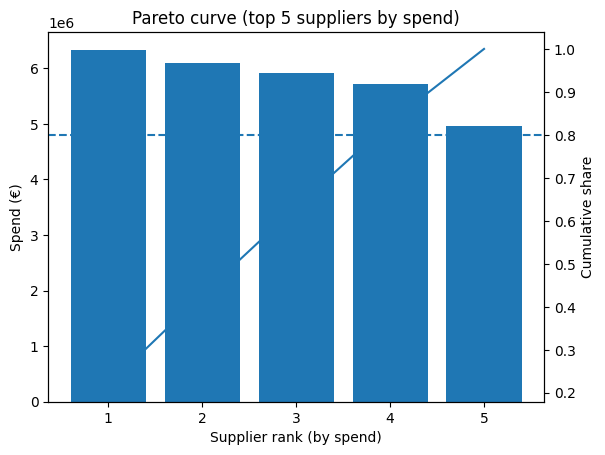

In [23]:
import matplotlib.pyplot as plt

top_n = min(20, len(pareto))
top = pareto.head(top_n).copy()

x = range(1, top_n + 1)

fig, ax = plt.subplots()
ax.bar(x, top["Total_Spend"].values)
ax.set_xlabel("Supplier rank (by spend)")
ax.set_ylabel("Spend (€)")

ax2 = ax.twinx()
ax2.plot(x, top["cum_share"].values)
ax2.axhline(0.80, linestyle="--")
ax2.set_ylabel("Cumulative share")

plt.title(f"Pareto curve (top {top_n} suppliers by spend)")
plt.show()